# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation
functions in analysis? What advantage do they have over linear models?

Linear models predict a raw numeric output with no constraints, which works well for continuous outcomes. But many outcomes are bounded, probabilities must lie in [0,1], counts must be non-negative, etc. GLMs apply a link function (or activation) that maps the unbounded linear predictor to the appropriate output space. This lets the model capture nonlinear relationships between features and the response while keeping the underlying structure interpretable and tractable.

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

Binary cross-entropy is -[y * log(p_hat) + (1-y) * log(1 - p_hat)]. It penalizes confident wrong predictions very heavily (because log(0) → -infinity) and rewards confident correct ones. It is also the negative log-likelihood of a Bernoulli distribution, so minimizing it is equivalent to maximum likelihood estimation, giving it a principled statistical foundation. The loss is convex in the parameters, so gradient descent reliably finds the global minimum.

3. True or false, and explain: Logistic regression is a linear model.

Partially true. The latent variable (log-odds) is linear in the features: b · x. But the predicted probability is a nonlinear transformation of that linear combination via the sigmoid. So logistic regression is linear in log-odds space, but nonlinear in probability space.

4. True or false, and explain: Logistic regression cannot be used for classification.

False. Logistic regression is routinely used for classification. It outputs a probability, and you apply a threshold (commonly 0.5) to assign a class label.

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

Not directly. The coefficient b_k represents the change in the log-odds for a 1-unit increase in x_k. The change in the predicted probability depends on the current value of p_hat — it is b_k * p_hat * (1 - p_hat), which is largest near p_hat = 0.5 and shrinks toward the tails.

6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

False. Although the sigmoid introduces nonlinearity in the output, logistic regression is still linear in the log-odds. It cannot learn interaction effects, polynomial relationships, or other complex patterns without explicit feature engineering (e.g., adding x1 * x2 or x^2 terms).

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

False. Logistic regression is better suited than OLS when the outcome is binary or categorical. But for continuous outcomes, OLS is perfectly appropriate, and simpler. The right model depends on the nature of the response variable.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


Q2.1

In [1]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

sns.set_theme(style='whitegrid')

df_raw = pd.read_csv(io.BytesIO(uploaded['data.csv']), sep=';')

cols = ['Debtor', 'Tuition fees up to date', 'Scholarship holder',
        'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target']
df = df_raw[cols].copy()

print('Missing values:')
print(df.isnull().sum())

df['dropout'] = (df['Target'] == 'Dropout').astype(int)
print(df['Target'].value_counts())

Saving data.csv to data.csv
Missing values:
Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


Q 2.2 - Debtor and Age at enrollment have positive coefficients, both predict higher dropout probability. Tuition fees up to date and Scholarship holder have negative coefficients, both predict lower dropout probability. Being up to date on tuition has by far the largest effect: an odds ratio of 0.078 means the odds of dropping out are about 92% lower for students current on payments compared to those who aren't, so yes, it strongly reduces dropout risk.

In [2]:
features = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']

X = df[features].values
y = df['dropout'].values

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X, y)

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr.coef_[0],
    'Odds Ratio': np.exp(lr.coef_[0])
})
print(coef_df.to_string(index=False))

                Feature  Coefficient  Odds Ratio
                 Debtor     0.530625    1.699995
Tuition fees up to date    -2.556542    0.077572
     Scholarship holder    -1.227442    0.293041
      Age at enrollment     0.049925    1.051193


Q 2.3 - Being up to date on tuition reduces predicted dropout probability by -0.5162 on average (about 52 percentage points). The gap between the two groups is roughly constant across all ages since tuition enters linearly in log-odds space. In absolute terms the gap is largest around ages 20–30 where the sigmoid is steepest, and compresses at older ages where baseline probabilities are already higher.

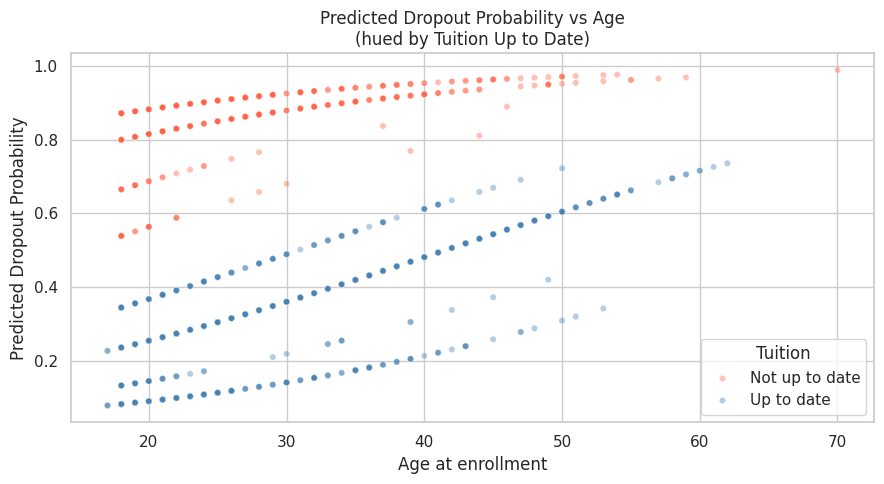

Average effect of being up to date on tuition: -0.5162


In [3]:
df['dropout_prob'] = lr.predict_proba(X)[:, 1]

fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=df, x='Age at enrollment', y='dropout_prob',
                hue='Tuition fees up to date',
                palette={0: 'tomato', 1: 'steelblue'}, alpha=0.4, s=20, ax=ax)
ax.set_ylabel('Predicted Dropout Probability')
ax.set_title('Predicted Dropout Probability vs Age\n(hued by Tuition Up to Date)')
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Not up to date', 'Up to date'], title='Tuition')
plt.tight_layout()
plt.show()

d0 = df[features].copy(); d0['Tuition fees up to date'] = 0
d1 = df[features].copy(); d1['Tuition fees up to date'] = 1
avg_effect = (lr.predict_proba(d1.values)[:,1] - lr.predict_proba(d0.values)[:,1]).mean()
print(f'Average effect of being up to date on tuition: {avg_effect:.4f}')

Q 2.4 - 76.2%. The model is much better at identifying non-dropouts (94.6% of them correct) than actual dropouts (37.3% caught). This reflects class imbalance, the model is biased toward predicting the majority class.

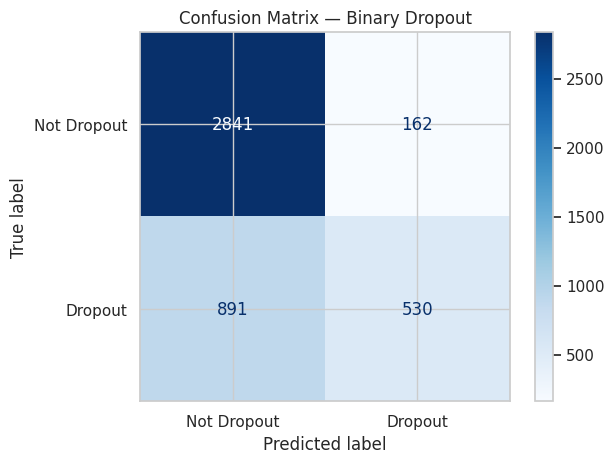

Accuracy: 0.7620


In [4]:
y_pred = lr.predict(X)

cm = confusion_matrix(y, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Not Dropout', 'Dropout']).plot(cmap='Blues')
plt.title('Confusion Matrix — Binary Dropout')
plt.show()

print(f'Accuracy: {accuracy_score(y, y_pred):.4f}')

Q 2.5 - The logistic model keeps all predictions inside (0, 1). The linear model produces values outside that range for some students, which is nonsensical as a probability. Both models rank students similarly, but only the logistic model gives valid, interpretable probabilities.

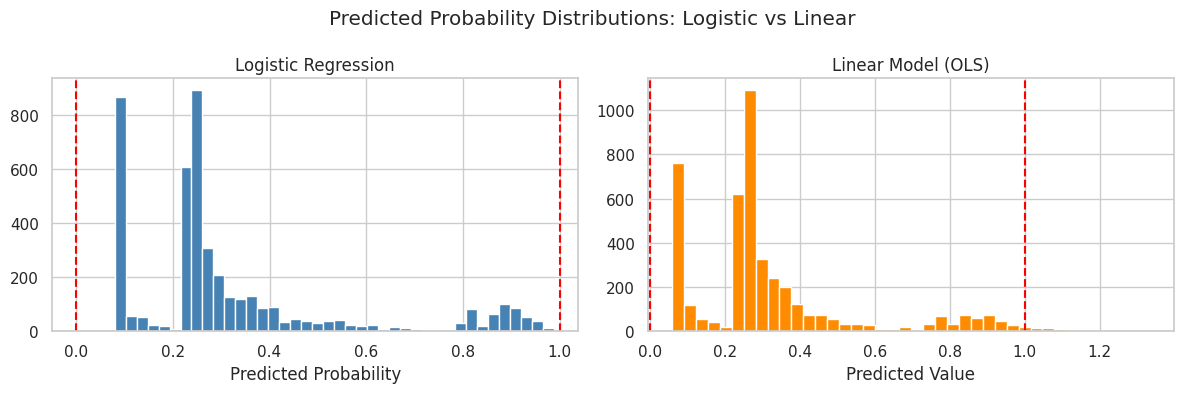

Linear predictions outside [0,1]: 57


In [5]:
ols = LinearRegression().fit(X, y)

prob_log = lr.predict_proba(X)[:, 1]
prob_lin = ols.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(prob_log, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--'); axes[0].axvline(1, color='red', linestyle='--')
axes[0].set_title('Logistic Regression'); axes[0].set_xlabel('Predicted Probability')

axes[1].hist(prob_lin, bins=40, color='darkorange', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--'); axes[1].axvline(1, color='red', linestyle='--')
axes[1].set_title('Linear Model (OLS)'); axes[1].set_xlabel('Predicted Value')

plt.suptitle('Predicted Probability Distributions: Logistic vs Linear')
plt.tight_layout(); plt.show()

print(f'Linear predictions outside [0,1]: {((prob_lin < 0) | (prob_lin > 1)).sum()}')

Q 2.6 - The highest-risk students are those who are in debt, not current on tuition, have no scholarship, and are older at enrollment. Tuition status is by far the dominant predictor.
Possible interventions: emergency tuition assistance or flexible payment plans for students falling behind; an early warning system that flags students with debt and overdue balances for advisor outreach, expanded scholarship eligibility targeting students with debt, and part-time or accelerated options for older students balancing outside obligations.

Q2.7 - The hard classification only predicts Dropout and Graduate, never Enrolled (accuracy 70.5%). The Enrolled class is essentially ignored because it's the smallest group and the model finds it cheaper to misclassify all of them. The confusion matrix shows all 794 Enrolled students assigned to either Dropout or Graduate.
The predicted probabilities tell a different story: .predict_proba assigns non zero probability to all three classes for every student (mean: Dropout 32%, Enrolled 18%, Graduate 50%). So the probabilities do "see" the Enrolled class even though the hard labels never pick it. This is a key limitation of hard classification with imbalanced data, the probabilities are more informative.

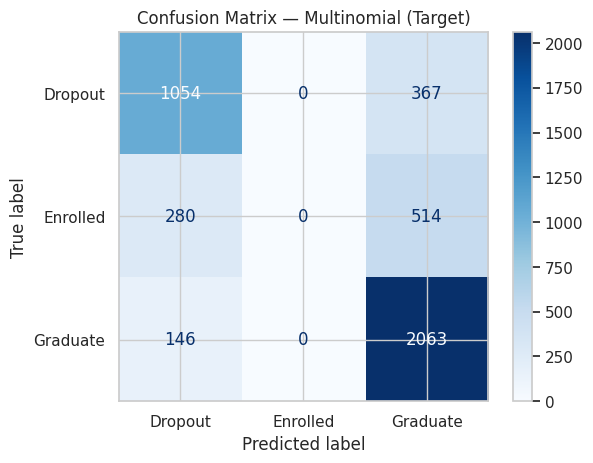

Classes predicted: ['Dropout' 'Graduate']
Accuracy: 0.7046
Dropout     0.321223
Enrolled    0.179474
Graduate    0.499303
dtype: float64


In [6]:
features_m = ['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']

Xm = df[features_m].values
ym = df['Target'].values

lrm = LogisticRegression(max_iter=1000, random_state=42)
lrm.fit(Xm, ym)

ym_pred = lrm.predict(Xm)
cm_m = confusion_matrix(ym, ym_pred, labels=lrm.classes_)
ConfusionMatrixDisplay(cm_m, display_labels=lrm.classes_).plot(cmap='Blues')
plt.title('Confusion Matrix — Multinomial (Target)'); plt.show()

print('Classes predicted:', np.unique(ym_pred))
print(f'Accuracy: {accuracy_score(ym, ym_pred):.4f}')

proba_df = pd.DataFrame(lrm.predict_proba(Xm), columns=lrm.classes_)
print(proba_df.mean())

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

Q3.1 - Drug has 106 missing values and Stage has 6,  these correspond to patients who were not randomized in the trial (observational follow-up only). We drop them via listwise deletion, going from 418 to 312 rows.

In [7]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

df_c = pd.read_csv(io.BytesIO(uploaded['cirrhosis.csv']))

cols = ['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']
df_c = df_c[cols].copy()

print(df_c.isnull().sum())
# Drug: 106 missing, Stage: 6 missing — these are patients not in the trial
# We drop rows with any missing values, going from 418 to 312 rows
df_c = df_c.dropna()

# Binary survival target: 1 = alive (C or CL), 0 = dead (D)
df_c['alive'] = (df_c['Status'] != 'D').astype(int)

# Dummy encode Edema, drop N as reference category
df_c = pd.get_dummies(df_c, columns=['Edema'], drop_first=False)
df_c = df_c.drop(columns=['Edema_N'])

# Encode Drug as binary
df_c['drug_binary'] = (df_c['Drug'] == 'D-penicillamine').astype(int)

Saving cirrhosis.csv to cirrhosis.csv
Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64


Q3.2 - Does the drug improve survival? Counterintuitively, no , the drug coefficient is slightly negative. This is consistent with the raw data: survival rates are 58.9% for D-penicillamine vs 61.0% for placebo. The drug did not improve outcomes in this trial.

Bilirubin: Negative coefficient,  higher bilirubin strongly predicts lower survival. Dead patients had mean bilirubin of 5.63 vs 1.67 for survivors, so bilirubin is a strong marker of disease severity.

Edema: Both edema types have negative coefficients. Edema_S (manageable with diuretics) reduces survival odds to 0.637x. Edema_Y (despite diuretics, severe) drops it to just 0.199x,  raw survival rate for Edema_Y patients is only 5%.

In [8]:
edema_cols = [c for c in df_c.columns if c.startswith('Edema_')]
features_c = edema_cols + ['drug_binary', 'Bilirubin']

Xc = df_c[features_c].values
yc = df_c['alive'].values

lrc = LogisticRegression(max_iter=1000, random_state=42)
lrc.fit(Xc, yc)

coef_c = pd.DataFrame({
    'Feature': features_c,
    'Coefficient': lrc.coef_[0],
    'Odds Ratio': np.exp(lrc.coef_[0])
})
print(coef_c.to_string(index=False))

    Feature  Coefficient  Odds Ratio
    Edema_S    -0.451483    0.636684
    Edema_Y    -1.613160    0.199257
drug_binary    -0.231952    0.792984
  Bilirubin    -0.351450    0.703667


Q3.3 - The drug is associated with a -0.0426 average change in survival probability (slightly negative, consistent with the coefficient). The placebo group sits marginally above D-penicillamine across all bilirubin levels. The drug never meaningfully increases survival at any bilirubin range in this model.

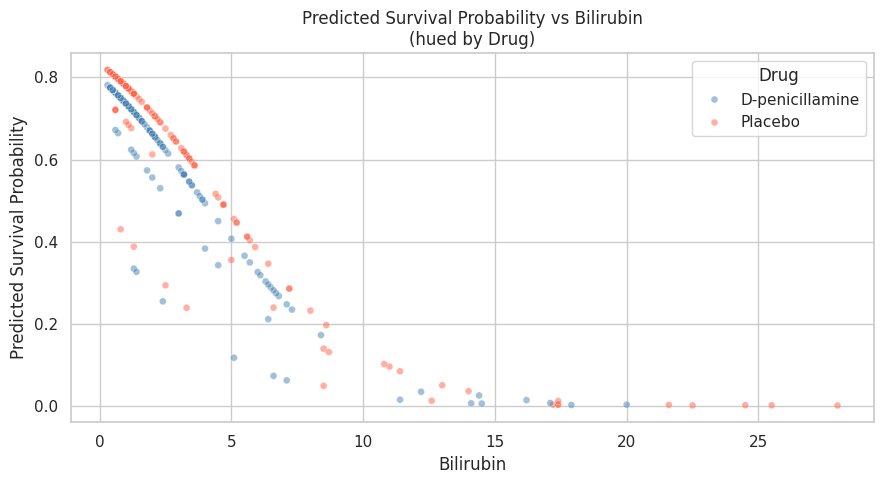

Average effect of drug on survival probability: -0.0426


In [9]:
df_c['survival_prob'] = lrc.predict_proba(Xc)[:, 1]

fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=df_c, x='Bilirubin', y='survival_prob', hue='Drug',
                palette={'D-penicillamine': 'steelblue', 'Placebo': 'tomato'},
                alpha=0.5, s=25, ax=ax)
ax.set_ylabel('Predicted Survival Probability')
ax.set_title('Predicted Survival Probability vs Bilirubin\n(hued by Drug)')
plt.tight_layout()
plt.show()

d0 = df_c[features_c].copy(); d0['drug_binary'] = 0
d1 = df_c[features_c].copy(); d1['drug_binary'] = 1
avg_drug_effect = (lrc.predict_proba(d1.values)[:,1] - lrc.predict_proba(d0.values)[:,1]).mean()
print(f'Average effect of drug on survival probability: {avg_drug_effect:.4f}')

Q3.4 - Accuracy: 73.7%. The model is much better at identifying survivors (91.4% correct) than predicting death (47.2% correct). It misses a lot of patients who actually died, relevant in a clinical setting where false negatives are costly.

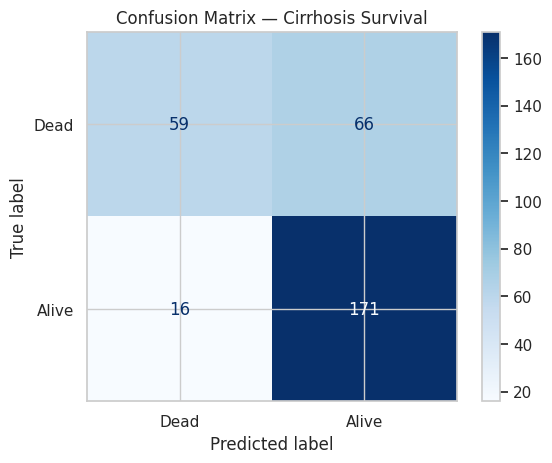

Accuracy: 0.7372


In [10]:
yc_pred = lrc.predict(Xc)
ConfusionMatrixDisplay(confusion_matrix(yc, yc_pred), display_labels=['Dead', 'Alive']).plot(cmap='Blues')
plt.title('Confusion Matrix — Cirrhosis Survival')
plt.show()

print(f'Accuracy: {accuracy_score(yc, yc_pred):.4f}')

Q3.5 - The linear model produces 15 predictions outside [0,1]. The logistic model keeps everything bounded. In a clinical setting this matters, telling a patient they have a -3% survival probability is meaningless.

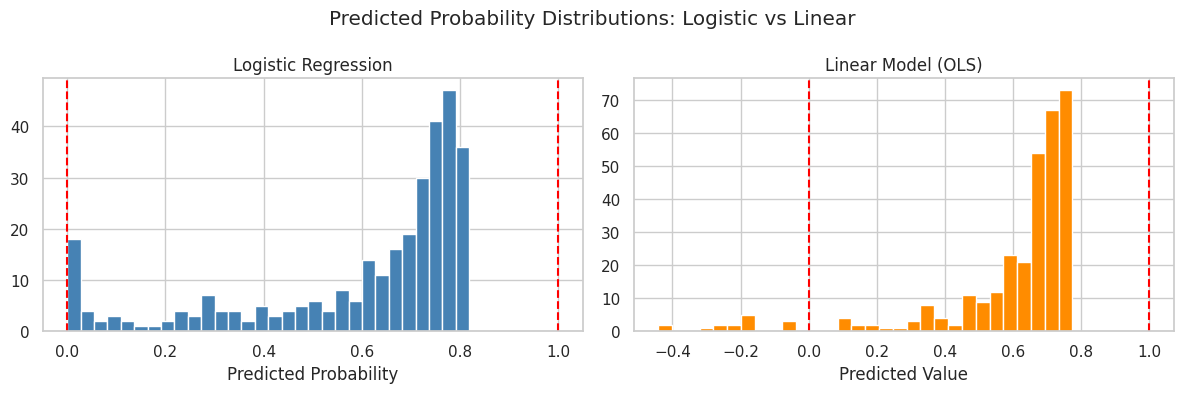

Linear predictions outside [0,1]: 15


In [11]:
olsc = LinearRegression().fit(Xc, yc)
prob_log = lrc.predict_proba(Xc)[:, 1]
prob_lin = olsc.predict(Xc)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(prob_log, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--'); axes[0].axvline(1, color='red', linestyle='--')
axes[0].set_title('Logistic Regression'); axes[0].set_xlabel('Predicted Probability')

axes[1].hist(prob_lin, bins=30, color='darkorange', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--'); axes[1].axvline(1, color='red', linestyle='--')
axes[1].set_title('Linear Model (OLS)'); axes[1].set_xlabel('Predicted Value')

plt.suptitle('Predicted Probability Distributions: Logistic vs Linear')
plt.tight_layout(); plt.show()

print(f'Linear predictions outside [0,1]: {((prob_lin < 0) | (prob_lin > 1)).sum()}')

Q3.6 - The hard classification only ever predicts Stage 3 and Stage 4, Stages 1 and 2 are never predicted (accuracy 43.3%). Stage 1 has only 21 patients so the model never finds it worth predicting. The confusion matrix shows every Stage 1 and 2 patient misclassified as Stage 3.
The predicted probabilities do assign non-zero probability to all four stages for every patient (mean: Stage 1 = 5.1%, Stage 2 = 21.5%, Stage 3 = 38.5%, Stage 4 = 34.9%). So the probabilities "know" about Stages 1 and 2 even though the hard labels never pick them, again, the probabilities are more informative than the hard classification.

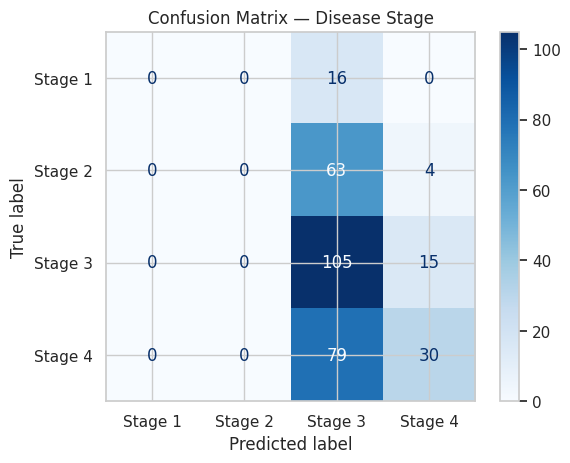

Classes predicted: [3 4]
Accuracy: 0.4327
1    0.0513
2    0.2147
3    0.3847
4    0.3494
dtype: float64


In [12]:
features_s = edema_cols + ['Bilirubin']
df_s = df_c.copy()
df_s['Stage'] = df_s['Stage'].astype(int)

Xs = df_s[features_s].values
ys = df_s['Stage'].values

lrs = LogisticRegression(max_iter=1000, random_state=42)
lrs.fit(Xs, ys)

ys_pred = lrs.predict(Xs)
ConfusionMatrixDisplay(confusion_matrix(ys, ys_pred, labels=lrs.classes_),
                       display_labels=[f'Stage {c}' for c in lrs.classes_]).plot(cmap='Blues')
plt.title('Confusion Matrix — Disease Stage')
plt.show()

print('Classes predicted:', np.unique(ys_pred))
print(f'Accuracy: {accuracy_score(ys, ys_pred):.4f}')
print(pd.DataFrame(lrs.predict_proba(Xs), columns=lrs.classes_).mean().round(4))

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?


The prediction is y_hat = b_0 + b_1x_1 + ... + b_Kx_K, so the derivative with respect to x_k is just b_k. A 1-unit increase in x_k changes the prediction by exactly b_k, no matter what the other features are or what the current prediction is. The effect is constant everywhere.

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?



Let L = b · x. Using the hint and the chain rule:
d(p_hat)/d(x_k) = [d/dL (e^L / (1 + e^L))] * [dL/d(x_k)]
= p_hat * (1 - p_hat) * b_k
Unlike the linear case, this changes as x changes, because p_hat itself changes with x. The effect of b_k on the predicted probability is not constant; it depends on where you currently are on the sigmoid curve.
The multiplier p_hat * (1 - p_hat) is maximized when p_hat = 0.5, where it equals 0.25. So at p_hat = 0.5, the effect of a 1-unit change in x_k on the predicted probability is approximately b_k * 0.25, meaning b_k * 4 is a reasonable ballpark estimate of the marginal effect when p_hat is near 0.5. As p_hat approaches 0 or 1 the multiplier shrinks toward zero, so the same coefficient b_k has much less impact on the predicted probability out in the tails.

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?


From the derivation in the problem:

log(p_hat / (1 - p_hat)) = b · x

The left side is the log odds ratio. Since b · x = b_0 + b_1x_1 + ... + b_Kx_K, a 1-unit increase in x_k increases the log odds by exactly b_k,  this is constant regardless of x, just like the linear model derivative in part 1.

Equivalently, exponentiating both sides: the odds are multiplied by exp(b_k) for each 1-unit increase in x_k. This is called the odds ratio and is the standard way to report logistic regression coefficients. For example, in Q2 the tuition coefficient was -2.557, so exp(-2.557) = 0.077, being up to date on tuition multiplies the dropout odds by 0.077, i.e. reduces them by about 92%.